# Выявление рисков в доставке компании CargaPronto

CargaPronto — логистический оператор, связывающий производственные хабы Пуэрто-Рико с потребителями в США. По результатам внутреннего аудита 55% заказов доставляются с задержкой, штрафы за нарушение SLA превысили бюджет на IT-инфраструктуру, крупные ритейлеры угрожают расторжением контрактов.

Департамент транспорта считает, что причина задержек — не в логистике, а в неоднородности клиентской базы (труднодоступная география, клиенты с высокой долей возвратов/отмен и т.д.).

**Гипотеза для проверки:** задержки связаны со спецификой профиля клиента, и если сегментировать базу (по географии и поведению), можно предсказывать риск задержки уже в момент оформления заказа.

- **Тип задачи:** бинарная классификация.
- **Модели:**
  - Логистическая регрессия — для оценки «нижней планки» качества, ценится за скорость и прозрачность.
  - CatBoostClassifier — градиентный бустинг для поиска сложных закономерностей.
- **Метрика качества:** ROC-AUC (оценивает способность ранжировать заказы по риску).
- **Целевой порог:** ROC-AUC > 0.75 на тестовой выборке считается удовлетворительным результатом.

Данные:

Профили клиентов:

| Признак | Описание |
|---|---|
| `customer_id` | уникальный ID клиента, ключ для связи с orders |
| `customer_lat` | широта местонахождения клиента |
| `customer_lon` | долгота местонахождения клиента |
| `recency` | дней с момента последнего заказа (RFM: Recency) |
| `total_orders` | общее количество заказов (RFM: Frequency) |
| `total_sales` | суммарная выручка от клиента (RFM: Monetary) |
| `avg_discount` | средний размер скидки клиента |
| `return_rate` | доля проблемных заказов (возвраты/отмены) |

Таблица заказов:

| Признак | Описание |
|---|---|
| `order_id` | уникальный номер заказа |
| `customer_id` | ключ для связи с customers |
| `order_date` | дата и время покупки |
| `category_name` | категория товара |
| `item_price` | стоимость товара |
| `shipping_mode` | режим доставки (Standard Class, First Class, Second Class, Same Day) |
| `late_delivery_risk` | **целевая переменная**: 1 — задержка, 0 — доставлено вовремя |

##  Импорт библиотек, выполнение базовых настроек

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [1]:
%pip install -q \
    jupyter \
    pandas==2.3.3 \
    numpy==1.26.4 \
    matplotlib \
    seaborn==0.13.2 \
    phik \
    scikit-learn==1.6.1 \
    mlxtend \
    optuna \
    catboost==1.2.10 \
    shap \
    python-dotenv \
    folium

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import optuna
import shap

## Загрузка данных, первичное знакомство

- Загрузим датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv` (пути: `'/datasets/ds_s18_customers.csv'` и `'/datasets/ds_s18_orders.csv'`).
- Затем проводем технический аудит данных.
- Выявим и устраним полные дубликаты строк.
- Выполним проверку целостности данных (ID-Check).
- Подготовим признаки, связанные с датой и временем.
- Создадим дополнительные колонки: `order_month`, `order_weekday`, `order_hour`.


In [3]:
# from dotenv import load_dotenv
# import os

# load_dotenv()

# FILES_URL = os.getenv('FILES_URL')

FILES_URL = 'https://code.s3.yandex.net'

In [4]:
# Random state
RANDOM_STATE=1703

TARGET_COL='late_delivery_risk'

In [5]:
def get_data():
    try:
        df_c = pd.read_csv('./datasets/ds_s18_customers.csv')
        df_o = pd.read_csv('./datasets/ds_s18_orders.csv')
        print('Файлы загружены из кеша')
    except Exception as e:
        df_c = pd.read_csv(FILES_URL + '/datasets/ds_s18_customers.csv')
        df_o = pd.read_csv(FILES_URL + '/datasets/ds_s18_orders.csv')

        df_c.to_csv('./datasets/ds_s18_customers.csv', index=False)
        df_o.to_csv('./datasets/ds_s18_orders.csv', index=False)

        print('Файлы загружены из сети')
    
    return df_c, df_o


In [6]:
df_c, df_o = get_data()

Файлы загружены из кеша


In [7]:
df_c.head()

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


In [8]:
df_o.head()

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


**Промежуточный вывод**

Таблицы успешно загружены. Переходим к предподготовке данных

In [9]:
# Вывод информации о датасете
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


In [10]:
# Вывод информации о датасете
df_o.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  object 
 4   category_name       180519 non-null  object 
 5   order_date          180519 non-null  object 
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 9.6+ MB


In [11]:
# Проверка на наличие пропусков с использованием assert
assert not df_c.isnull().any().any(), 'В таблице customers найдены пропуски'
assert not df_o.isnull().any().any(), 'В таблице orders найдены пропуски'

In [12]:
# Проверка на наличие полных дубликатов строк с использованием assert
assert not df_c.duplicated().any(), 'В таблице customers найдены полные дубликаты строк'
assert not df_o.duplicated().any(), 'В таблице orders найдены полные дубликаты строк'

In [13]:
# Проверка на наличие дубликатов id
assert not df_o['order_id'].duplicated().any(), 'В таблице orders найдены дубликаты id заказов'
assert not df_c['customer_id'].duplicated().any(), 'В таблице customers найдены дубликаты id клиентов'

In [14]:
# Проверка на наличие пропусков в объединенном датасете
assert set(df_o['customer_id']) - set(df_c['customer_id']) == set(), 'В заказах есть клиенты, которые не зарегистрированы в таблице customers'
assert set(df_c['customer_id']) - set(df_o['customer_id']) == set(), 'В таблице customers есть клиенты, которые не появились в таблице orders'


**Промежуточный вывод**

Для полной корректности типов требуется преобразовать тип признака `order_date` в таблице заказов к `datetime`

В данных не обнаружено пропусков

В данных не обнаружено полных дубликатов строк и дубликатов id заказов

В данных не выявлено проблем с целостностью. Таблицы клиентов и заказов можно соединить без пропусков

In [15]:
# Функция для подготовки данных о заказах
def prepare_orders_data(df_o):
    # Преобразование даты в datetime
    df_o['order_date'] = pd.to_datetime(df_o['order_date'])

    # Создание новых признаков
    df_o['order_month'] = df_o['order_date'].dt.month - 1 # чтобы месяц был в диапазоне 0-11
    df_o['order_weekday'] = df_o['order_date'].dt.weekday
    df_o['order_hour'] = df_o['order_date'].dt.hour

    return df_o

In [16]:
# Применение функции подготовки данных о заказах
df_o = prepare_orders_data(df_o)
df_o.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            180519 non-null  int64         
 1   customer_id         180519 non-null  int64         
 2   late_delivery_risk  180519 non-null  int64         
 3   shipping_mode       180519 non-null  object        
 4   category_name       180519 non-null  object        
 5   order_date          180519 non-null  datetime64[ns]
 6   item_price          180519 non-null  float64       
 7   order_month         180519 non-null  int32         
 8   order_weekday       180519 non-null  int32         
 9   order_hour          180519 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(3), object(2)
memory usage: 11.7+ MB


**Промежуточный вывод**

Для подготовки признаков в таблице заказов создана функция. Она приводит признак с датой заказа к корректному типу и выделяет из даты месяц, день недели и час

Можем переходить к EDA

## EDA

На этом этапе цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, изучим и удалим географические аномалии.


### Проверка баланса классов

В задаче заявлено, что задержек 55%. Проверим эту информацию:

In [17]:
# Доля задержек
df_o[TARGET_COL].value_counts(normalize=True)

late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

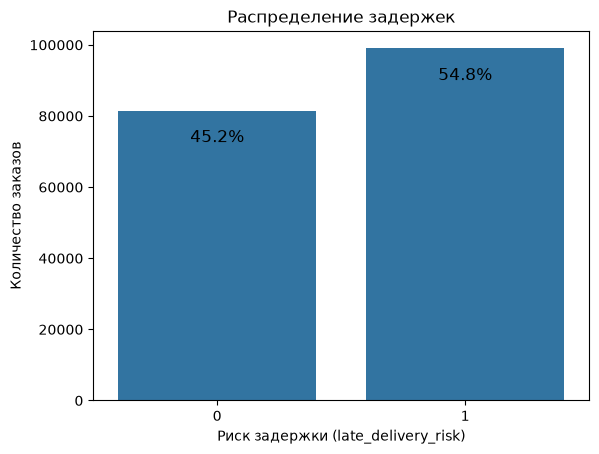

In [18]:
# График распределения задержек
ax = sns.countplot(x=TARGET_COL, data=df_o)
plt.title('Распределение задержек')
plt.xlabel('Риск задержки (late_delivery_risk)')
plt.ylabel('Количество заказов')

# Добавим на график процент каждого класса
total = len(df_o)
for p in ax.patches:
    ax.annotate(
        f"{100 * int(p.get_height()) / total:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height() - 10000),
        ha='center', va='bottom', fontsize=12
    )

plt.show()

**Промежуточный вывод**

Баланс целевого класса подтвержден. Задержек примерно 55%

### Географический аудит

Построим диаграмму рассеяния координат клиентов и изучить выбросы

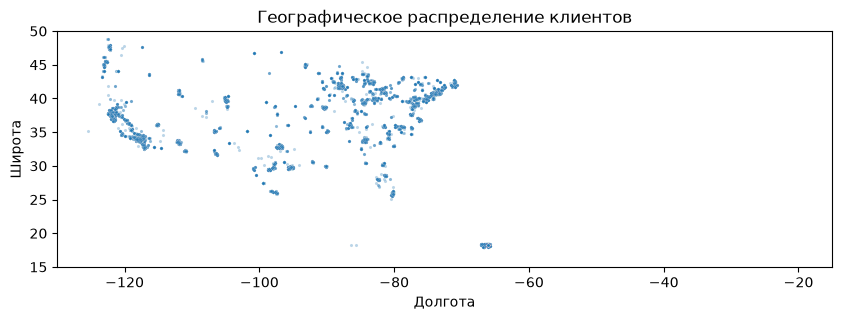

In [19]:
# Диаграмма рассеяния координат заказов
plt.figure(figsize=(10, 6))
sns.scatterplot(x='customer_lon', y='customer_lat', data=df_c, s=5, alpha=0.3)
plt.xlim(-130, -15)
plt.ylim(15, 50)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Географическое распределение клиентов')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

В дополнение к диаграмме построим карту с помощью библиотеки folium

In [20]:
import folium

def get_map(df_c, n_points=1000):
    df_plot = df_c
    if len(df_c) > n_points:
        df_plot = df_c.sample(n=n_points, random_state=RANDOM_STATE)

    m = folium.Map(
        location=[df_c['customer_lat'].median(), df_c['customer_lon'].median()],
        zoom_start=2,
        tiles='OpenStreetMap',
        zoom_control=False,
        scrollWheelZoom=False,
        dragging=False,
        doubleClickZoom=False,
        boxZoom=False,
        touchZoom=False,
        attributionControl=False,
    )

    for lat, lon in df_plot[['customer_lat', 'customer_lon']].values:
        folium.CircleMarker(
            location=[lat, lon],
            radius=2,
            color='steelblue',
            fill=True,
            fill_opacity=0.5,
        ).add_to(m)

    folium.PolyLine(
        locations=[[0, -125], [60, -125]],  # [lat, lon]
        color="red",
        weight=2,
        opacity=0.8,
    ).add_to(m)

    folium.PolyLine(
        locations=[[0, -20], [60, -20]],
        color="red",
        weight=2,
        opacity=0.8,
    ).add_to(m)

    return m

get_map(df_c)


### Удаление аномалий

На карте замечено небольшое количество аномалий. Это точки с долготой (lon) выходящей за границы [-125, -20]. Пользователей с такими координатами необходимо удалить вместе с их заказами:


In [21]:
# Функция для удаления аномалий
def remove_anomalies(df_c, df_o):
    df_c_clean = df_c[df_c['customer_lon'].between(-125, -20)].copy()
    df_o_clean = df_o[df_o['customer_id'].isin(df_c_clean['customer_id'])].copy()

    return df_c_clean, df_o_clean


In [22]:
# Применение функции для удаления аномалий
df_c_before, df_o_before = len(df_c), len(df_o)
df_c, df_o = remove_anomalies(df_c, df_o)
print(f"Удалено клиентов: {df_c_before - len(df_c)}")
print(f"Удалено заказов: {df_o_before - len(df_o)}")

Удалено клиентов: 156
Удалено заказов: 1430


In [23]:
# Вывод пользователей на карте после удаления аномалий
get_map(df_c)

### Зависимости между признаками

Рассчитаем зависимости в таблице товаров. Перед расчетом удалим из таблицы признаки, значения которых почти всегда будут уникальными и не несут полезной информации для модели `order_id`, `customer_id` и `order_date`


In [24]:
# Функция для построения тепловой карты
def heatmap(df):
    plt.figure(figsize=(15, 10))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title("Phik Correlation Matrix", fontsize=16)
    plt.show()

In [25]:
# Расчет корреляции между признаками
df_o_phik = df_o.drop(columns=['order_id', 'customer_id', 'order_date']).phik_matrix(
    ['late_delivery_risk', 'item_price', 'order_month', 'order_weekday', 'order_hour']
)

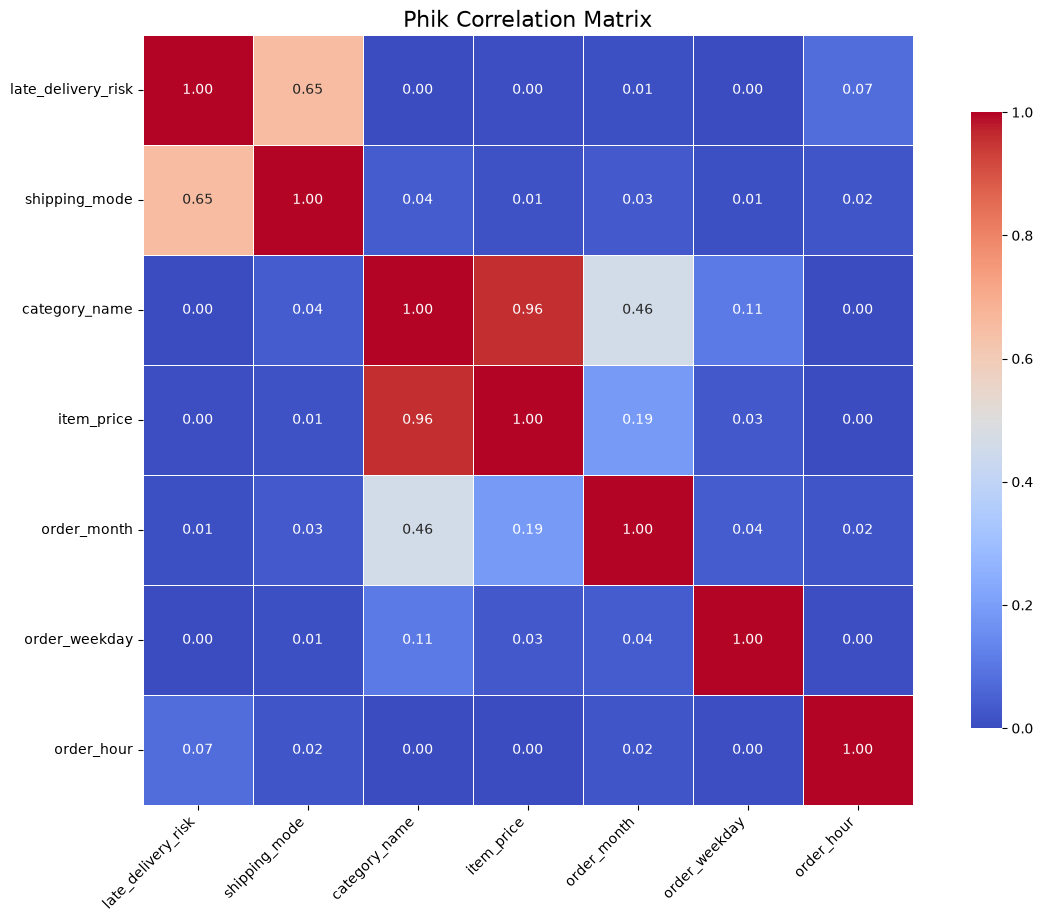

In [26]:
heatmap(df_o_phik)

In [27]:
df_o_phik[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

shipping_mode    0.653699
order_hour       0.074537
order_month      0.008065
item_price       0.004763
order_weekday    0.001739
category_name    0.000000
Name: late_delivery_risk, dtype: float64

**Промежуточный вывод**

Связь признаков с целевой переменной `late_delivery_risk`:
- самый сильный сигнал даёт `shipping_mode` (φk ≈ 0.65) — режим доставки заметно связан с риском задержки;
- временные признаки связаны слабо: `order_hour` ≈ 0.07, `order_weekday` ≈ 0.002, `order_month` ≈ 0.008;
- `item_price` почти не связан с целевой (≈ 0.004), `category_name` — связи нет (≈ 0.00).

Вывод: одних признаков заказа недостаточно для сильного прогноза — кроме `shipping_mode`, полезный сигнал слабый. Это согласуется с гипотезой проекта: для роста качества нужны признаки профиля клиента (география и поведение), которые будут получены на этапах кластеризации.


**Промежуточный вывод**

Единственная сильная связь между признаками — пара `category_name` и `item_price` (φk ≈ 0.96): цена почти однозначно определяется категорией товара. Остальные пары связаны слабо, то есть выраженной мультиколлинеарности в данных нет.

Для линейной модели такая пара избыточна. Оба признака оставлены в пайплайне, но эффект дублирования сглаживает elasticnet-регуляризация, а по SHAP итоговой модели вклад `item_price` близок к нулю — на качество это не влияет.

### Зависимость между значениями признаков и целевой переменной

In [28]:
# Функция для построения графиков histplot + boxplot по данным для непрерывных числовых признаков
def plot_numeric_distributions(df, target=None):
    fig, axes = plt.subplots(len(df.columns), 2, figsize=(12, len(df.columns) * 3))

    # если одна колонка — axes не массив
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        data = df[col].dropna().to_numpy()
        # явные границы бинов: обход бага np.histogram на больших массивах (bins=int)
        bins = np.linspace(data.min(), data.max(), 31)

        axes[i][0].hist(data, bins=bins)
        axes[i][0].grid()
        axes[i][0].set_title(f'Распределение {col}')
        axes[i][0].set_xlabel(f'{col} (единицы)')
        axes[i][0].set_ylabel('Количество')

        if target is not None:
            mask = df[col].notna()
            binned = pd.cut(df.loc[mask, col], bins=bins, include_lowest=True)
            mean_by_bin = target.loc[mask].groupby(binned, observed=False).mean()
            centers = (bins[:-1] + bins[1:]) / 2
            y = mean_by_bin.to_numpy() * axes[i][0].get_ylim()[1]
            axes[i][0].plot(
                centers, y,
                color='red',
                label='Средняя доля риска опоздания'
            )
            axes[i][0].legend()

        sns.boxplot(data=df, x=col, ax=axes[i][1])
        axes[i][1].set_title(f'Boxplot {col}')
        axes[i][1].set_xlabel(f'{col} (единицы)')
        axes[i][1].set_ylabel('')

    plt.show()

# Функция для построения countplot по данным для дискретных числовых признаков
def plot_discrete_distributions(df, target = None):
    fig, axes = plt.subplots(
        len(df.columns),
        1,
        figsize=(12, len(df.columns) * 3)
    )

    # если одна колонка — axes не массив
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Частоты категорий: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Количество')
        axes[i].tick_params(axis='x', rotation=30)

        if target is not None:
            (target.groupby(df[col]).mean() * axes[i].get_ylim()[1]).plot(
                ax=axes[i],
                color='red',
                label='Средняя доля риска опоздания'
            )

        axes[i].grid()
        axes[i].legend()
        
    plt.tight_layout()
    plt.show()
    
# Функция для построения графиков countplot и barplot по данным для категориальных признаков
def plot_categorical_distributions(df, target, top_n = 20):
    fig, axes = plt.subplots(
        len(df.columns),
        2,
        figsize=(14, len(df.columns) * 4)
    )

    # если одна колонка
    if len(df.columns) == 1:
        axes = [axes]

    data = df.copy()

    for i, col in enumerate(df.columns):
        data[col] = data[col].fillna('missing')
        top = data[col].value_counts().nlargest(top_n).index
        plot_data = data[data[col].isin(top)]

        # 1. Countplot (частоты)
        sns.countplot(
            data=plot_data,
            y=col,
            ax=axes[i][0]
        )
        axes[i][0].set_title(f'{col} — count')
        axes[i][0].tick_params(axis='x', rotation=30)

        # 2. Barplot (средний target)
        sns.barplot(
            y=plot_data[col],
            x=target,
            estimator=np.mean,
            errorbar=None,
            ax=axes[i][1]
        )
        axes[i][1].set_title(f'{col} — mean(target)')

    plt.tight_layout()
    plt.show()

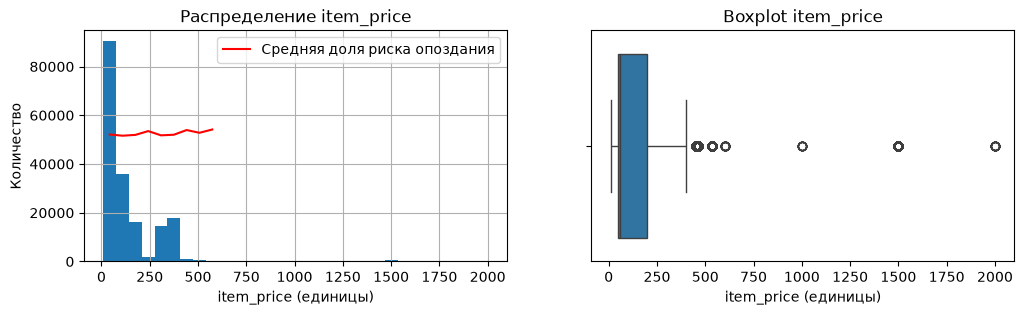

In [29]:
plot_numeric_distributions(
    df_o[['item_price']],
    df_o[TARGET_COL]
)


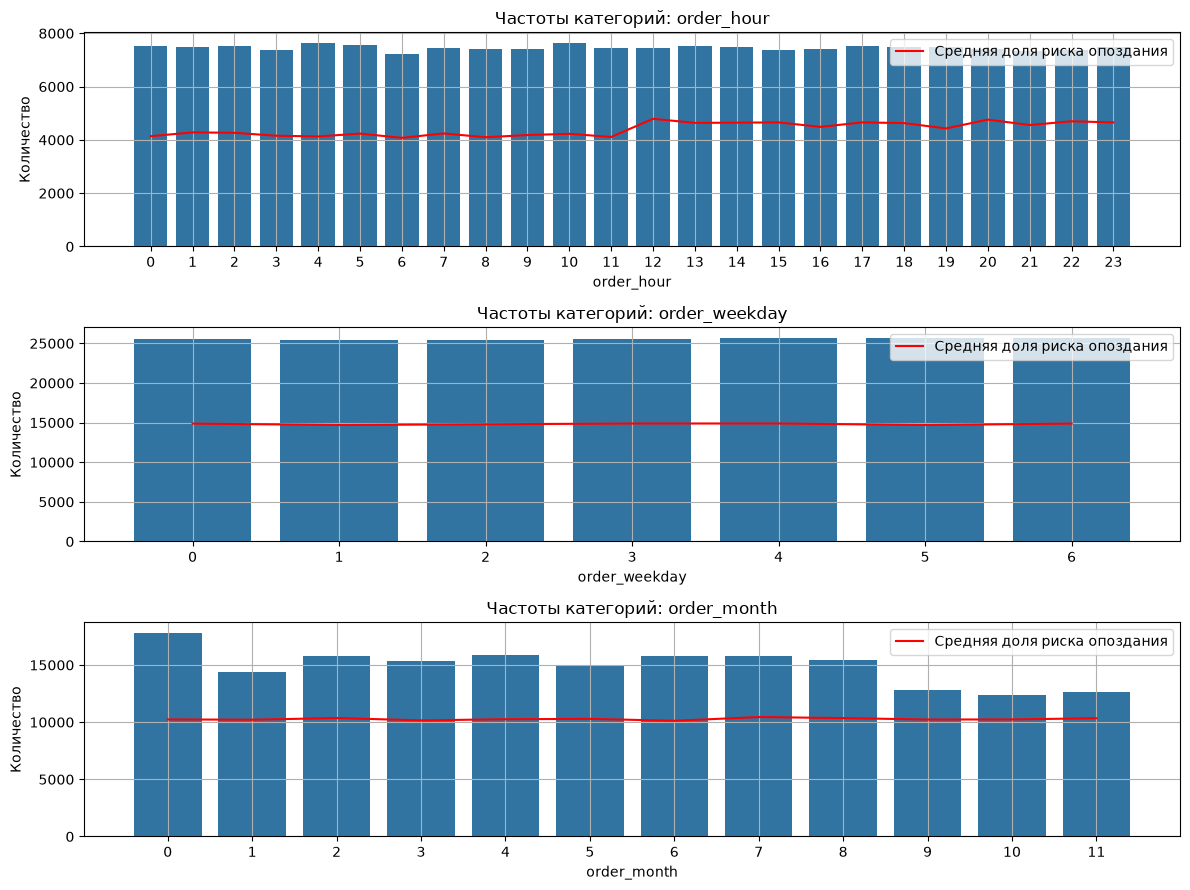

In [30]:
plot_discrete_distributions(
    df_o[['order_hour', 'order_weekday', 'order_month']],
    df_o[TARGET_COL]
)

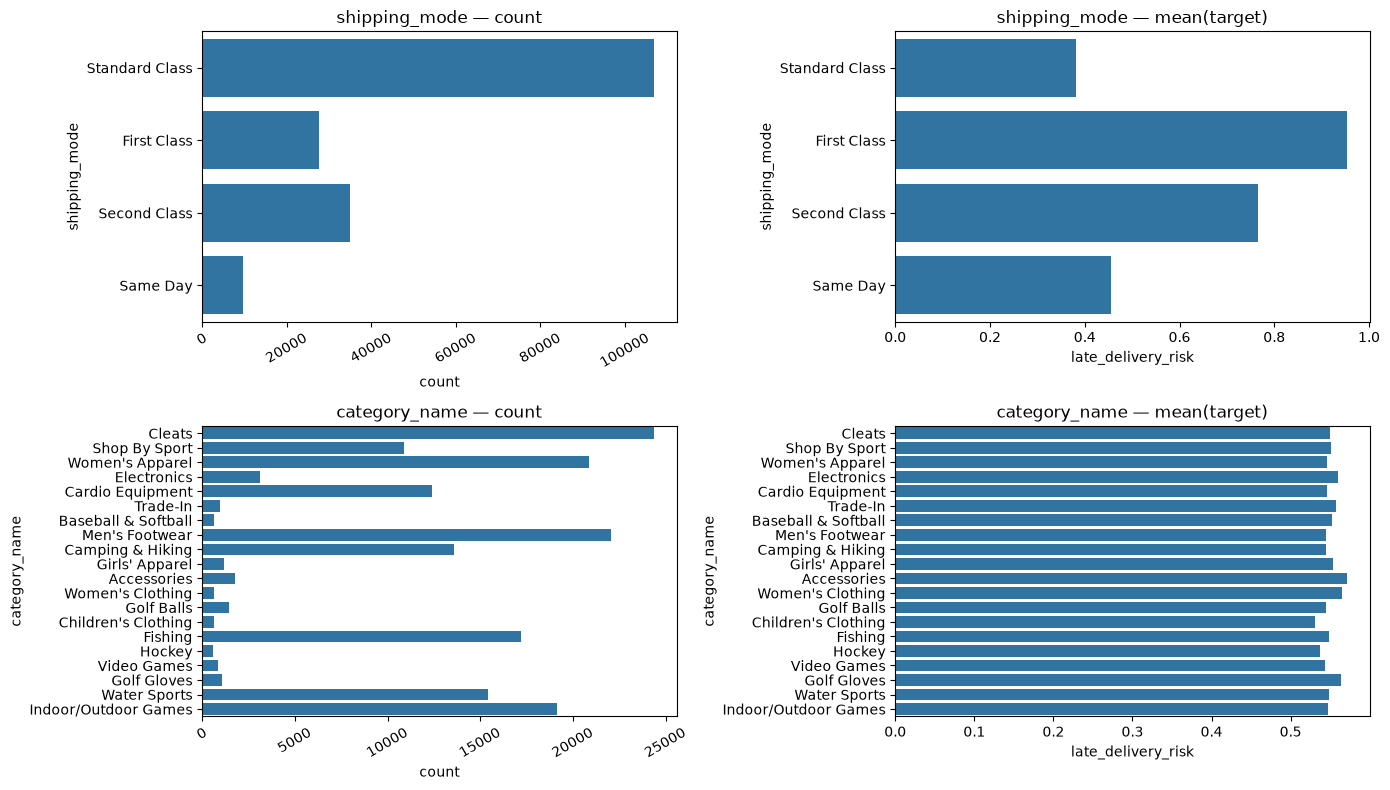

In [31]:
plot_categorical_distributions(
    df_o[['shipping_mode', 'category_name']],
    df_o[TARGET_COL]
)


**Промежуточный вывод**

- **Выбросы:** у `item_price` распределение сильно скошено вправо — основная масса до ~400, есть редкие значения около 1000–2000. У дискретных признаков (`order_hour`, `order_weekday`, `order_month`) аномальных частот нет. У `shipping_mode` и `category_name` дисбаланс классов (Standard Class и топ-категории доминируют), но это не выбросы в смысле аномальных значений.
- **Связь с таргетом:** сильная только у `shipping_mode` — First/Second Class заметно выше риск, Standard Class ниже. У `order_hour` слабый сдвиг: после полудня риск чуть выше. `item_price`, `order_weekday`, `order_month` и `category_name` почти не связаны с риском опоздания (линия/доля таргета почти плоская).

##  Разделение на выборки

Разделим датафрейм с заказами на выборки. Но используем не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

1. Разделим данные из датафрейма с заказами на три выборки в соотношении 60:20:20.

2. После разделения обязательно убедимся, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

In [32]:
from sklearn.model_selection import GroupShuffleSplit

# Функция для проверки пересечения множеств ID клиентов в выборках
def assert_no_overlap(df_train, df_val, df_test):
    assert set(df_train['customer_id']).isdisjoint(df_val['customer_id']), "Ошибка: Есть пересечение клиентов между train и val выборками!"
    assert set(df_train['customer_id']).isdisjoint(df_test['customer_id']), "Ошибка: Есть пересечение клиентов между train и test выборками!"
    assert set(df_val['customer_id']).isdisjoint(df_test['customer_id']), "Ошибка: Есть пересечение клиентов между val и test выборками!"

# Функция для разделения данных о заказах на выборки
def split_orders(df_o):
    groups = df_o['customer_id']
    # temp (80%) and test (20%)
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    temp_idx, test_idx = next(gss1.split(df_o, groups=groups))
    df_temp = df_o.iloc[temp_idx]
    df_test = df_o.iloc[test_idx]

    # temp into train (60%) and val (20%)
    groups_temp = df_temp['customer_id']
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
    train_idx, val_idx = next(gss2.split(df_temp, groups=groups_temp))
    df_train = df_temp.iloc[train_idx]
    df_val = df_temp.iloc[val_idx]

    assert_no_overlap(df_train, df_val, df_test)

    return df_train, df_val, df_test


In [33]:
df_o_train, df_o_val, df_o_test = split_orders(df_o)

In [34]:
# Проверка размеров выборок
sizes = pd.DataFrame({
    'orders': [len(df_o_train), len(df_o_val), len(df_o_test)],
    'customers': [
        df_o_train['customer_id'].nunique(),
        df_o_val['customer_id'].nunique(),
        df_o_test['customer_id'].nunique(),
    ],
}, index=['train', 'val', 'test'])
sizes['orders_share'] = (sizes['orders'] / len(df_o)).round(3)
sizes['customers_share'] = (sizes['customers'] / df_o['customer_id'].nunique()).round(3)
sizes

,orders,customers,orders_share,customers_share
train,108095,12297,0.604,0.6
val,35719,4099,0.199,0.2
test,35275,4100,0.197,0.2


**Промежуточный вывод**

Заказы разделены на train / val / test через `GroupShuffleSplit` по `customer_id`: доли близки к 60:20:20, множества клиентов не пересекаются (проверено `assert`).

Такое разделение исключает утечку: один клиент целиком попадает только в одну выборку, поэтому модель не может «узнать» его по адресу и привычкам.

## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Нам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберем нужные признаки — используем колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Инициализируем пайплайны для логистической регрессии и `CatBoostClassifier`.

3. Подберем гиперпараметры для моделей

4. Обучим лучшие варианты моделей.

5. Оценим качество обеих моделей на валидационной выборке.

In [35]:
# Подготовка выборок для обучения моделей
num_cols = np.array(['item_price'])
date_cols = np.array(['order_hour', 'order_weekday', 'order_month'])
cat_cols = np.array(['shipping_mode', 'category_name'])
cols = np.concatenate([num_cols, date_cols, cat_cols])

X_train = df_o_train[cols]
y_train = df_o_train[TARGET_COL]

X_val = df_o_val[cols]
y_val = df_o_val[TARGET_COL]


In [36]:
# Необходимые импорты
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Класс для преобразования числовых признаков в sin и cos
class SinCosTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.cols = X.columns
        return self

    def transform(self, X):
        X_ = X.copy()
        for col in self.cols:
            X_[f'{col}_sin'] = np.sin(2 * np.pi * X_[col] / (X_[col].max()+1))
            X_[f'{col}_cos'] = np.cos(2 * np.pi * X_[col] / (X_[col].max()+1))
            X_.drop(columns=col, inplace=True)
        return X_
    
    # Функция для получения новых имён колонок после трансформации
    def get_feature_names_out(self, input_features=None):
        output_cols = []
        for col in self.cols:
            output_cols.append(f'{col}_sin')
            output_cols.append(f'{col}_cos')
        return output_cols
 
   

In [37]:
# Подготовка пайплайна для lr модели
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def add_preprocessor_to_lr(model, num_cols, cat_cols, date_cols):
    return Pipeline([
        ('preprocessor', ColumnTransformer([
                ('num', StandardScaler(), num_cols.tolist()),
                ('date', SinCosTransformer(), date_cols.tolist()),
                ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
            ])
        ),
        ('model', model)
    ])


In [38]:
# Функция для запуска исследования
def run_study(objective):
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )

    study.optimize(objective, n_trials=30, show_progress_bar=True)

    return study

In [39]:
# Подготовка поиска гиперпараметров для lr модели
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr_default_params = {
    'solver': 'saga',
    'penalty': 'elasticnet',
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
}

def objective_lr(
    X_train, 
    y_train,
    X_val, 
    y_val, 
    num_cols, 
    cat_cols, 
    date_cols
    ):
    def objective(trial: optuna.trial.Trial) -> dict:
        params = {
            'C': trial.suggest_float('C', 0.01, 100),
            'l1_ratio': trial.suggest_float('l1_ratio', 0, 1),
            **lr_default_params,
        }

        model = add_preprocessor_to_lr(
            LogisticRegression(**params),
            num_cols=num_cols,
            cat_cols=cat_cols,
            date_cols=date_cols,
        )

        model.fit(X_train, y_train)

        return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    return objective


In [40]:
# Подготовка поиска гиперпараметров для catboost модели
from catboost import CatBoostClassifier

catb_default_params = {
    'eval_metric': 'AUC',
    'early_stopping_rounds': 50,
    'auto_class_weights': 'Balanced',
    'random_seed': RANDOM_STATE,
    'thread_count': -1,
}

def fit_catb(X_train, y_train, X_val, y_val, cat_cols, params):
    model = CatBoostClassifier(
        cat_features=cat_cols,
        **catb_default_params,
        **params,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=0,
    )
    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    return model, auc


def objective_catb(X_train, y_train, X_val, y_val, cat_cols):
    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'iterations': trial.suggest_int('iterations', 500, 2000, step=100),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        }
        _, auc = fit_catb(X_train, y_train, X_val, y_val, cat_cols, params)
        return auc

    return objective


In [41]:
studies = {}

In [42]:
studies['lr'] = run_study(objective_lr(
    X_train, 
    y_train, 
    X_val, 
    y_val, 
    num_cols, 
    cat_cols,
    date_cols
))


[I 2026-08-04 00:34:24,727] A new study created in memory with name: no-name-38c5a856-34b1-49c6-846d-10c9080222cf


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-04 00:34:31,118] Trial 0 finished with value: 0.7315250119478256 and parameters: {'C': 10.253663514930077, 'l1_ratio': 0.19004822678449063}. Best is trial 0 with value: 0.7315250119478256.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[I 2026-08-04 00:36:59,544] Trial 27 finished with value: 0.7315331784511695 and parameters: {'C': 8.080004011813617, 'l1_ratio': 0.7966858514836228}. Best is trial 24 with value: 0.7315365476483615.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-04 00:37:05,280] Trial 28 finished with value: 0.7315278459999748 and parameters: {'C': 38.789695692281164, 'l1_ratio': 0.9079861360368289}. Best is trial 24 with value: 0.7315365476483615.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-04 00:37:09,860] Trial 29 finished with value: 0.7315341220797065 and parameters: {'C': 7.943744425516876, 'l1_ratio': 0.8363309793853984}. Best is trial 24 with value: 0.7315365476483615.


In [43]:
studies['catb'] = run_study(objective_catb(
    X_train,
    y_train,
    X_val,
    y_val,
    np.concatenate([cat_cols, date_cols]),
))


[I 2026-08-04 00:37:09,932] A new study created in memory with name: no-name-5afc16c2-a9ee-4883-908d-12b9360f48a2


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-04 00:37:18,333] Trial 0 finished with value: 0.8043224339571962 and parameters: {'learning_rate': 0.012660384042052011, 'depth': 4, 'iterations': 1100, 'l2_leaf_reg': 5.617043627161186}. Best is trial 0 with value: 0.8043224339571962.
[I 2026-08-04 00:37:19,944] Trial 1 finished with value: 0.7582270602303594 and parameters: {'learning_rate': 0.012838246111987457, 'depth': 6, 'iterations': 1500, 'l2_leaf_reg': 6.568347288991658}. Best is trial 0 with value: 0.8043224339571962.
[I 2026-08-04 00:37:24,619] Trial 2 finished with value: 0.8036893716211013 and parameters: {'learning_rate': 0.019278596454472413, 'depth': 5, 'iterations': 1600, 'l2_leaf_reg': 1.7701413143564555}. Best is trial 0 with value: 0.8043224339571962.
[I 2026-08-04 00:37:26,479] Trial 3 finished with value: 0.7583427497222834 and parameters: {'learning_rate': 0.020589008085720034, 'depth': 5, 'iterations': 900, 'l2_leaf_reg': 1.5358869932104204}. Best is trial 0 with value: 0.8043224339571962.
[I 2026-08-

In [44]:
for name, study in studies.items():
    print(f'Модель {name}, AUC: {study.best_value}')

Модель lr, AUC: 0.7315365476483615
Модель catb, AUC: 0.8045288685323233


**Промежуточный вывод**

Базовые модели на признаках заказа (валидационная выборка):

| Модель | ROC-AUC |
|---|---|
| LogisticRegression | 0.732 |
| CatBoostClassifier | 0.805 |

CatBoost заметно опережает линейную модель — значит в данных есть нелинейные зависимости, которые логистическая регрессия не улавливает. Существенную часть отрыва даёт передача календарных признаков в `cat_features`: CatBoost работает с часом заказа как с категорией и вытягивает из него сигнал, который φk оценивал как слабый (≈ 0.07).

Это точка отсчёта. Дальше проверим, добавят ли качества признаки профиля клиента (география и поведение).

##  Кластеризация по признакам, связанным с местоположением
На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.


In [45]:
CLASTER_COLS_COORDS = ['customer_lat', 'customer_lon']
df_c[CLASTER_COLS_COORDS].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_lat,20496.0,29.802401,9.821774,17.982491,18.265627,33.357388,39.319367,48.781933
customer_lon,20496.0,-84.523688,20.193052,-123.718552,-97.988876,-76.615067,-66.370552,-65.825951


K-Means считает евклидово расстояние, и оси с большим разбросом начинают влиять сильнее. В координатах `customer_lon` разброс сильнее чем у `customer_lat`, поэтому требуется масштабирование, применим `StandardScaler`

Для защиты от утечки данных `KMeans` будем обучать только на данных тех пользователей, чьи заказы попали в тренировочную выборку

Перед применением `KMeans` определим оптимальное значение гиперпараметка `n_clusters` (количество групп) с помощью метода локтя:

In [46]:
# Функция для разбиения данных о клиентов на группы в соответствии с разбиением заказов
def split_customers(df_c, df_o_train, df_o_val, df_o_test):
    df_c_train = df_c[df_c['customer_id'].isin(df_o_train['customer_id'])]
    df_c_val = df_c[df_c['customer_id'].isin(df_o_val['customer_id'])]
    df_c_test = df_c[df_c['customer_id'].isin(df_o_test['customer_id'])]

    return df_c_train, df_c_val, df_c_test

In [47]:
# Разделение клиентов на группы
df_c_train, df_c_val, df_c_test = split_customers(df_c, df_o_train, df_o_val, df_o_test)

In [48]:
# Функция для создания пайплайна с KMeans
from sklearn.cluster import KMeans

def get_kmeans_pipe(n_clusters, random_state=RANDOM_STATE):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=n_clusters, random_state=random_state))
    ])

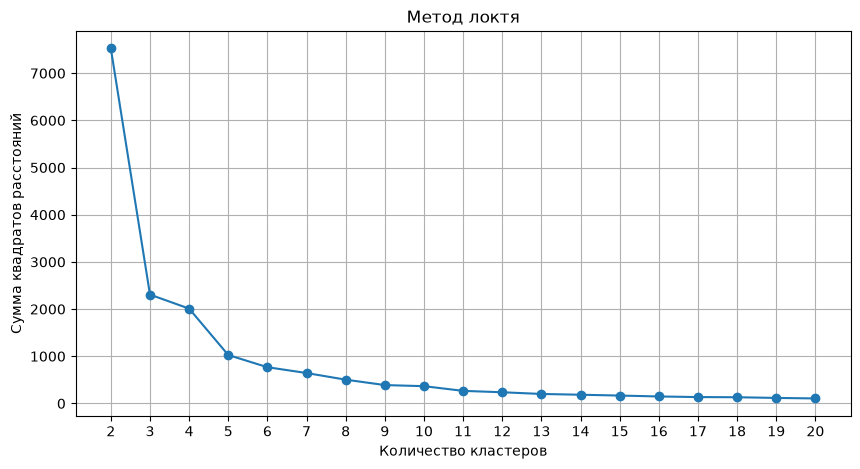

In [49]:
# График метода локтя
inertia = []
k_range = range(2, 21)
for n_clusters in k_range:
    pipe = get_kmeans_pipe(n_clusters)
    pipe.fit(df_c_train[CLASTER_COLS_COORDS])
    inertia.append(pipe['kmeans'].inertia_)

plt.figure(figsize=(10, 5))
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.grid()
plt.plot(k_range, inertia, marker='o')
plt.xticks(k_range)
plt.show()

In [50]:
# Дополнительное оптимального количества кластеров.
# Доля улучшения относительно кластеризации с 2 кластерами.
_ = np.array(inertia)
((_[0] - _[1:]) / _[0]).round(2)


array([0.69, 0.73, 0.86, 0.9 , 0.91, 0.93, 0.95, 0.95, 0.96, 0.97, 0.97,
       0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.99])

Скорость уменьшения ошибки начинает сильно падать при 9 кластерах, поэтому применим n_clusters=9

In [51]:
# Создание пайплайна для KMeans с 9 кластерами
kmeans_coords = get_kmeans_pipe(n_clusters=9)
kmeans_coords.fit(df_c_train[CLASTER_COLS_COORDS])

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=9, random_state=1703))])

In [52]:
# центроиды кластеров
centers = kmeans_coords['scaler'].inverse_transform(kmeans_coords['kmeans'].cluster_centers_)

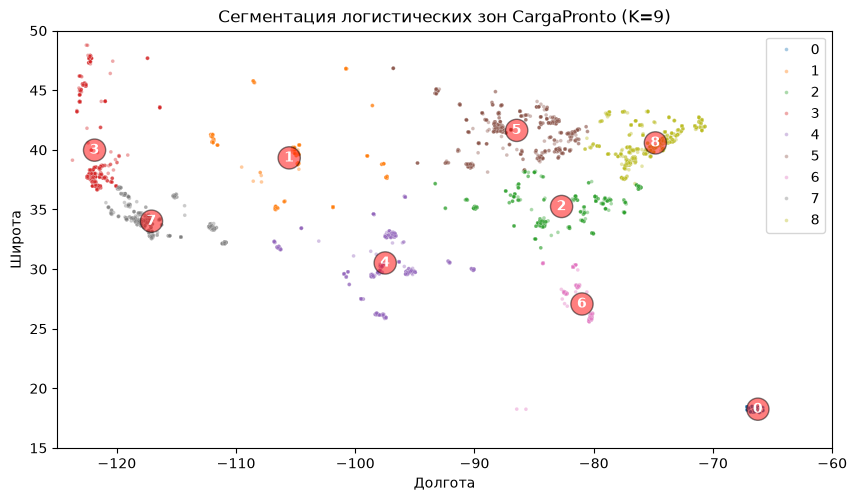

In [53]:
# Диаграмма рассеяния клиентов с разбивкой по кластерам
df_plot = df_c_train.copy()
df_plot['geo_cluster'] = kmeans_coords.predict(df_plot[CLASTER_COLS_COORDS])
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='customer_lon', y='customer_lat',
    hue='geo_cluster',
    palette='tab10',
    s=7, alpha=0.4,
    legend='full',
)

# Добавим центры кластеров на scatterplot координат
for i, (lat, lon) in enumerate(centers):
    plt.text(
        lon, lat, str(i),
        fontsize=10, fontweight='bold',
        color='white',
        ha='center', va='center',
        bbox=dict(boxstyle='circle', facecolor='red', edgecolor='black', alpha=0.5,),
    )
plt.legend()
plt.xlim(-125, -60)
plt.ylim(15, 50)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Сегментация логистических зон CargaPronto (K=9)')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [54]:
# Средний силуэт по кластерам
from sklearn.metrics import silhouette_score

silhouette_score(
    kmeans_coords['scaler'].transform(df_c_train[CLASTER_COLS_COORDS]),
    kmeans_coords.predict(df_c_train[CLASTER_COLS_COORDS]),
    metric='euclidean'
)

0.7543768054862764

**Промежуточный вывод**

- Координаты масштабированы (`StandardScaler`): разброс `lon` заметно больше, чем у `lat`.
- Scaler и K-Means обучены только на клиентах из train — без утечки в val/test.
- По методу локтя основной выигрыш набирается до K≈6 (~90% относительно K=2), к K=9 — ~95%, дальше прирост почти нулевой. Выбрано **K=9**.
- На карте зоны разделяются географически (запад/центр США, восток, Пуэрто-Рико и т.п.); признак `geo_cluster` готов к добавлению в модель.


География кластеров:

| Кластер | Интерпретация                             |
| ------- | ----------------------------------------- |
| 0       | Пуэрто-Рико  |
| 1       | Горный запад / центральные штаты          |
| 2       | Восточная часть США                       |
| 3       | Западное побережье (Калифорния/побережье) |
| 4       | Техасский/юго-центральный регион          |
| 5       | Центрально-восточная зона                 |
| 6       | Флорида                                   |
| 7       | Северо-западные регионы                   |
| 8       | Юго-восток                                |

Получили хорее разделение на кластеры, прослеживается сопоставление с географией местности. Так же средний силуэт составляет примерно 0.75


##  Кластеризация по признакам профилей клиентов

1. Подготовим векторы признаков — используем пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполним предобработку данных и обеспечим защиту от утечек.
3. Используем метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируем полученные кластеры: дадим статистическую характеристику и опишем самые яркие группы.
5. Визуализируем положение кластеров с помощью t-SNE.


In [55]:
CLASTER_COLS_NUMS = ['recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']
df_c[CLASTER_COLS_NUMS].describe().T

,count,mean,std,min,25%,50%,75%,max
recency,20496.0,221.054791,199.321732,1.00,76.000000,160.000000,308.000000,1126.000000
total_orders,20496.0,3.182816,2.430372,1.00,1.000000,3.000000,5.000000,15.000000
total_sales,20496.0,1599.828742,1508.261915,8.47,252.880005,1293.685009,2619.100048,9436.610088
return_rate,20496.0,0.042867,0.156431,0.00,0.000000,0.000000,0.000000,1.000000
avg_discount,20496.0,0.101729,0.048269,0.00,0.076250,0.100000,0.123011,0.250000


K-Means считает евклидово расстояние, и оси с большим разбросом начинают влиять сильнее. В признаках датасета слишком большой разброс значений, поэтому требуется масштабирование, применим `StandardScaler`

Для защиты от утечки данных `KMeans` будем обучать только на данных тех пользователей, чьи заказы попали в тренировочную выборку

Перед применением `KMeans` определим оптимальное значение гиперпараметка `n_clusters` (количество групп) с помощью метода локтя:

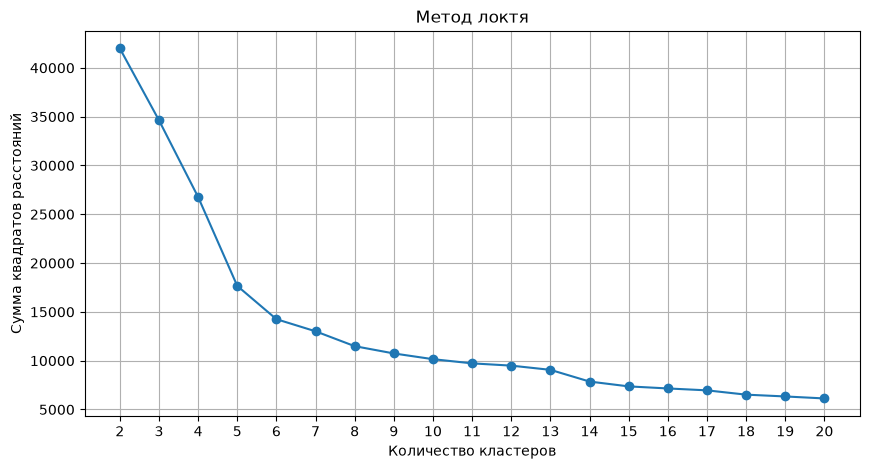

In [56]:
# График метода локтя
inertia = []
k_range = range(2, 21)
for n_clusters in k_range:
    pipe = get_kmeans_pipe(n_clusters)
    pipe.fit(df_c_train[CLASTER_COLS_NUMS])
    inertia.append(pipe['kmeans'].inertia_)

plt.figure(figsize=(10, 5))
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.grid()
plt.plot(k_range, inertia, marker='o')
plt.xticks(k_range)
plt.show()

In [57]:
# Дополнительное оптимального количества кластеров.
# Доля улучшения относительно кластеризации с 2 кластерами.
_ = np.array(inertia)
((_[0] - _[1:]) / _[0]).round(2)

array([0.18, 0.36, 0.58, 0.66, 0.69, 0.73, 0.74, 0.76, 0.77, 0.77, 0.78,
       0.81, 0.82, 0.83, 0.83, 0.84, 0.85, 0.85])

Скорость уменьшения ошибки начинает сильно падать при 8 кластерах, поэтому применим n_clusters=8

In [58]:
# Создание пайплайна для KMeans с 8 кластерами
kmeans_nums = get_kmeans_pipe(n_clusters=8)
kmeans_nums.fit(df_c_train[CLASTER_COLS_NUMS])

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(random_state=1703))])

In [59]:
# Статистика по кластерам
df_stats = df_c_train[CLASTER_COLS_NUMS].copy()
df_stats['cluster'] = kmeans_nums.predict(df_stats[CLASTER_COLS_NUMS])
df_stats.groupby('cluster').mean()

,recency,total_orders,total_sales,return_rate,avg_discount
cluster,,,,,
0,671.216681,2.665520,1384.933764,0.008259,0.099299
1,261.179736,5.543172,3015.366808,0.015574,0.102376
2,67.106333,1.028828,261.410974,0.000000,0.170748
3,124.992157,1.098039,342.039138,0.987435,0.100425
4,272.223573,3.351263,1651.979774,0.003264,0.101930
5,65.372925,1.015861,298.883726,0.000000,0.046973
6,226.816888,8.145161,4706.977880,0.041678,0.100751
7,309.869492,4.418644,2313.831787,0.319512,0.102071


In [60]:
# Таблица кластеров с раскраской
(
    df_stats.groupby('cluster').mean()
    .apply(lambda x: (x - x.min()) / (x.max() - x.min()))
    .style.background_gradient(cmap='coolwarm', axis=1)
)

,recency,total_orders,total_sales,return_rate,avg_discount
cluster,,,,,
0,1.000000,0.231391,0.252729,0.008364,0.422753
1,0.323197,0.635029,0.619484,0.015772,0.447608
2,0.002861,0.001819,0.000000,0.000000,1.000000
3,0.098407,0.011527,0.018137,1.000000,0.431849
4,0.341426,0.327578,0.312799,0.003305,0.444009
5,0.000000,0.000000,0.008429,0.000000,0.000000
6,0.266478,1.000000,1.000000,0.042208,0.434477
7,0.403564,0.477295,0.461678,0.323578,0.445143


In [61]:
# Размер кластеров
df_stats.groupby('cluster').size()

cluster
0    1163
1    2270
2    2116
3     255
4    2138
5    2711
6    1054
7     590
dtype: int64

**Характеристика кластеров**:

0. «Спящие» — давно не заказывали (recency ~670), мало заказов и скромная выручка.
1. «Лояльные середняки» — стабильная частота (~5–6 заказов) и хороший чек при низком return_rate.
2. «Новички со скидкой» — свежие разовые клиенты (≈1 заказ) с высокой avg_discount (~17%).
3. «Проблемные» — почти все заказы с возвратом/отменой (return_rate ≈ 0.99), высокий операционный риск. При этом данный кластер самый малочисленный
4. «Умеренные постоянные» — средняя активность (~3 заказа), низкий return_rate, обычный discount.
5. «Новички без скидки» — свежие разовые клиенты при низкой avg_discount (~5%).
6. «VIP» — самые частые и денежные (~8 заказов, ~4700 sales), умеренный return_rate.
7. «Возвратные середняки» — средняя активность при заметно повышенном return_rate (~32%).

Самые проблемные кластеры - это 3 и 7


In [62]:
cluster_names = [
    "Спящие",
    "Лояльные середняки",
    "Новички со скидкой",
    "Проблемные",
    "Умеренные постоянные",
    "Новички без скидки",
    "VIP",
    "Возвратные середняки"
]

In [63]:
# Снижение размерности признаков
from sklearn.manifold import TSNE

# Инициализируем t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
# Применяем t-SNE к масштабированным данным
df_tsne = tsne.fit_transform(
    kmeans_nums['scaler'].transform(df_c_train[CLASTER_COLS_NUMS])
)
# Преобразуем результат в DataFrame
df_tsne = pd.DataFrame(df_tsne, columns=['x', 'y'])

df_tsne['cluster'] = df_stats['cluster'].to_numpy()

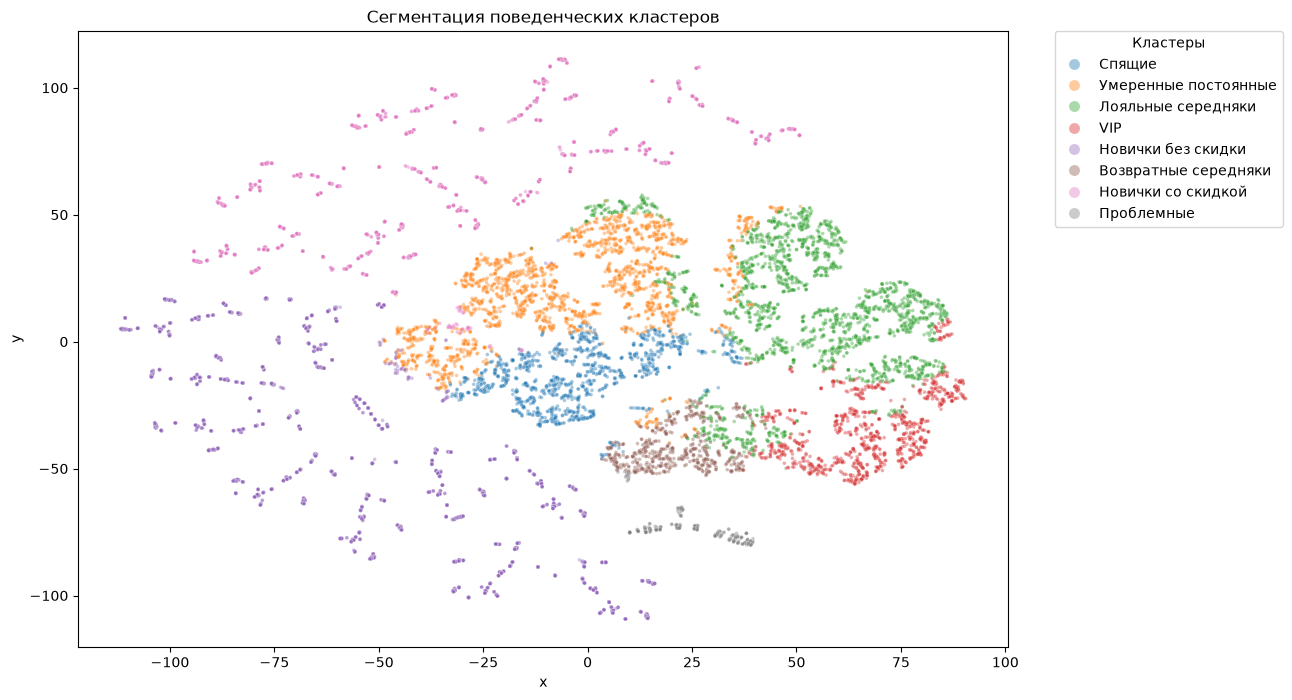

In [64]:
plt.figure(figsize=(12, 8))
# Создадим отображаемые имена для кластеров
df_tsne['cluster_name'] = df_tsne['cluster'].map(
    {i:cluster_names[i] for i in range(len(cluster_names))}
)
scatter = sns.scatterplot(
    data=df_tsne,
    x='x', y='y',
    hue='cluster_name',
    palette='tab10',
    s=7, alpha=0.4,
)
scatter.legend(title="Кластеры", bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0, markerscale=3)
plt.title('Сегментация поведенческих кластеров')
plt.show()

Визуализация показывает достаточно хорошо разделимые поведенческие сегменты. Большинство кластеров формируют отдельные плотные области, что говорит о наличии выраженной структуры в данных и корректности выделенных групп. При этом наблюдаются небольшие зоны пересечения между некоторыми кластерами, что может указывать на пользователей с пограничным поведением или плавные переходы между сегментами. В целом кластеризация выглядит качественной: основные группы хорошо отделены, а количество смешанных объектов невелико.

Есть несколько зон с переходами между кластерами (например, между умеренно постоянными и лояльными пользователями), что может говорить о плавном изменении поведения, а не о жёстких границах.

**Промежуточный вывод**

- RFM-признаки масштабированы (`StandardScaler`), K-Means обучен только на train-клиентах.
- По локтю выбран **K=8**: дальше inertia падает медленнее.
- Сегменты интерпретируемы — от VIP и лояльных до новичков и «проблемных» с return_rate ≈ 1.
- t-SNE показывает разделение кластеров в 2D; признак `beh_cluster` готов к добавлению в модель.


##  Обучение модели на новых признаках

1. Добавим результаты кластеризаций в данные для обучения моделей.
2. Обучим финальные версиии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитаем итоговые значения метрики ROC−AUC на валидационной выборке.
   

In [65]:
# Функция для добавления признаков кластеров в данные
def add_cluster_cols(df_c, df_o, kmeans_coords, kmeans_nums):
    df_clusters = pd.DataFrame({
        'customer_id': df_c['customer_id'],
        'geo_cluster': kmeans_coords.predict(df_c[CLASTER_COLS_COORDS]),
        'beh_cluster': kmeans_nums.predict(df_c[CLASTER_COLS_NUMS])
    })

    return df_o.merge(
        df_clusters,
        on='customer_id',
        how='left',
    )


In [66]:
# Функция для полной обработки данных
def get_processed_data(df_c, df_o, *, skip_cluster_cols=False):
    df_o = prepare_orders_data(df_o)
    df_c, df_o = remove_anomalies(df_c, df_o)
    
    if not skip_cluster_cols:
        df_o = add_cluster_cols(df_c, df_o, kmeans_coords, kmeans_nums)

    return df_c, df_o

In [67]:
# Пересборка данных с признаками кластеров
df_c, df_o = get_processed_data(*get_data())
df_o_train, df_o_val, df_o_test = split_orders(df_o)

df_o_train.head()


Файлы загружены из кеша


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour,geo_cluster,beh_cluster
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75,0,2,22,0,5
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75,0,5,12,0,5
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75,0,5,11,7,5
7,179248,19486,1,First Class,Sporting Goods,2018-01-13 10:21:00,327.75,0,5,10,6,2
8,179247,19485,1,Second Class,Sporting Goods,2018-01-13 10:00:00,327.75,0,5,10,0,2


In [68]:
# Указание новых списков признаков
num_cols = np.array(['item_price'])
date_cols = np.array(['order_hour', 'order_weekday', 'order_month'])
cat_cols = np.array(['shipping_mode', 'category_name', 'geo_cluster', 'beh_cluster'])
cols = np.concatenate([num_cols, date_cols, cat_cols])

In [69]:
# Отделение признаков и целевой переменной
X_train = df_o_train[cols]
y_train = df_o_train[TARGET_COL]
X_val = df_o_val[cols]
y_val = df_o_val[TARGET_COL]

In [70]:
# Подбор гиперпараметров lr на расширенных признаках
studies['lr_cluster_new'] = run_study(objective_lr(
    X_train, y_train, X_val, y_val, num_cols, cat_cols, date_cols
))

[I 2026-08-04 00:39:46,160] A new study created in memory with name: no-name-11bf3807-bf34-4932-b2a0-99a700cd7061


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-04 00:39:52,684] Trial 0 finished with value: 0.7429539146325355 and parameters: {'C': 10.253663514930077, 'l1_ratio': 0.19004822678449063}. Best is trial 0 with value: 0.7429539146325355.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[I 2026-08-04 00:42:58,177] Trial 27 finished with value: 0.742965244508055 and parameters: {'C': 76.27828164593556, 'l1_ratio': 0.8022675739066735}. Best is trial 11 with value: 0.7429657194888621.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-04 00:43:04,549] Trial 28 finished with value: 0.7429656118265457 and parameters: {'C': 90.83074720730548, 'l1_ratio': 0.924178605200197}. Best is trial 11 with value: 0.7429657194888621.


/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-08-04 00:43:11,476] Trial 29 finished with value: 0.7429655864942362 and parameters: {'C': 98.31739042917516, 'l1_ratio': 0.6994219195821019}. Best is trial 11 with value: 0.7429657194888621.


In [71]:
# Подбор гиперпараметров catb на расширенных признаках
studies['catb_cluster_new'] = run_study(objective_catb(
    X_train, y_train, X_val, y_val, np.concatenate([cat_cols, date_cols]),
))

[I 2026-08-04 00:43:11,542] A new study created in memory with name: no-name-e3888879-54b1-42b7-87a2-7f3f99cccefa


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-04 00:43:18,062] Trial 0 finished with value: 0.8032008411948093 and parameters: {'learning_rate': 0.012660384042052011, 'depth': 4, 'iterations': 1100, 'l2_leaf_reg': 5.617043627161186}. Best is trial 0 with value: 0.8032008411948093.
[I 2026-08-04 00:43:20,759] Trial 1 finished with value: 0.7695166526276063 and parameters: {'learning_rate': 0.012838246111987457, 'depth': 6, 'iterations': 1500, 'l2_leaf_reg': 6.568347288991658}. Best is trial 0 with value: 0.8032008411948093.
[I 2026-08-04 00:43:22,941] Trial 2 finished with value: 0.7693872187743929 and parameters: {'learning_rate': 0.019278596454472413, 'depth': 5, 'iterations': 1600, 'l2_leaf_reg': 1.7701413143564555}. Best is trial 0 with value: 0.8032008411948093.
[I 2026-08-04 00:43:26,595] Trial 3 finished with value: 0.7956091817893853 and parameters: {'learning_rate': 0.020589008085720034, 'depth': 5, 'iterations': 900, 'l2_leaf_reg': 1.5358869932104204}. Best is trial 0 with value: 0.8032008411948093.
[I 2026-08-

In [72]:
# Сохранение результатов
results = {name: study.best_value for name, study in studies.items()}

In [73]:
# Добавление результатов работы моделей с изначальными параметрами и новыми признаками
model = add_preprocessor_to_lr(
    LogisticRegression(**studies['lr'].best_params, **lr_default_params),
    num_cols=num_cols,
    cat_cols=cat_cols,
    date_cols=date_cols
)
model.fit(X_train, y_train)
results['lr_cluster_old'] = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

_, auc = fit_catb(
    X_train, y_train, X_val, y_val,
    cat_cols=np.concatenate([cat_cols, date_cols]),
    params=studies['catb'].best_params,
)

results['catb_cluster_old'] = auc

/Users/a1/Desktop/learning/ml_for_newbie/ml-identifying-risks-in-delivery/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [74]:
# Вывод топа моделей по ROC-AUC
results = pd.DataFrame(results, index=['ROC-AUC']).T.sort_values(by='ROC-AUC', ascending=False)
results

,ROC-AUC
catb_cluster_new,0.810436
catb,0.804529
catb_cluster_old,0.785849
lr_cluster_new,0.742966
lr_cluster_old,0.742952
lr,0.731537


**Промежуточный вывод**

- У логистической регрессии кластеры дают прирост ~**+0.011** (0.732 → 0.743) — профиль клиента добавляет сигнал, которого нет в признаках заказа.
- У CatBoost прирост скромнее: 0.805 → **0.810** (~+0.006). Часть сигнала о клиенте бустинг, видимо, уже добирает из остальных признаков.
- Повторный Optuna у LogReg качества не добавляет (разница < 0.001): важен сам факт новых признаков, а не переподбор гиперпараметров.
- У CatBoost же повторный подбор гиперпараметров под расширенный набор признаков заметно помогает: `catb_cluster_old` (0.786, старые параметры + новые признаки) явно проигрывает `catb_cluster_new` (0.810, параметры подобраны заново).
- Лучший вариант на val — **CatBoost + кластеры** (AUC ≈ **0.810**). Его берём дальше как основной.


## Дополнительное задание — подбор лучшего количества кластеров

Рассмотрим количество кластеров как гиперпараметр всей системы и найдем ту «степень детализации», которая даст максимальный прирост ROC-AUC.

In [75]:
# Подготовка поиска гиперпараметров для catboost модели с кластеризацией
def objective_catb_with_kmeans(df_c_train, df_o_train, df_c_val, df_o_val):
    def objective(trial: optuna.trial.Trial) -> float:
        # Подготовка гиперпараметров
        params_catb = {
            'learning_rate': trial.suggest_float('catb__learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('catb__depth', 3, 10),
            'iterations': trial.suggest_int('catb__iterations', 500, 2000, step=100),
            'l2_leaf_reg': trial.suggest_float('catb__l2_leaf_reg', 1.0, 10.0, log=True),
        }

        params_kmeans_geo = {
            'n_clusters': trial.suggest_categorical('kmeans_geo__n_clusters', [4,8,12,16,20]),
        }

        params_kmeans_beh = {
            'n_clusters': trial.suggest_categorical('kmeans_beh__n_clusters', [6, 12, 18, 24, 30]),
        }

        # Подготовка кластеризации
        kmeans_geo = get_kmeans_pipe(n_clusters=params_kmeans_geo['n_clusters']).fit(df_c_train[CLASTER_COLS_COORDS])
        kmeans_beh = get_kmeans_pipe(n_clusters=params_kmeans_beh['n_clusters']).fit(df_c_train[CLASTER_COLS_NUMS])

        # Добавление признаков кластеров в данные
        df_o_train_cluster = add_cluster_cols(
            df_c_train,
            df_o_train,
            kmeans_geo,
            kmeans_beh,
        )
        
        df_o_val_cluster = add_cluster_cols(
            df_c_val,
            df_o_val,
            kmeans_geo,
            kmeans_beh,
        )
        
        num_cols = np.array(['item_price'])
        date_cols = np.array(['order_hour', 'order_weekday', 'order_month'])
        cat_cols = np.array(['shipping_mode', 'category_name', 'geo_cluster', 'beh_cluster'])
        cols = np.concatenate([num_cols, date_cols, cat_cols])

        _, auc = fit_catb(
            df_o_train_cluster[cols], df_o_train_cluster[TARGET_COL],
            df_o_val_cluster[cols], df_o_val_cluster[TARGET_COL],
            np.concatenate([cat_cols, date_cols]), 
            params_catb
        )
        
        return auc

    return objective

In [76]:
# Свежая инициализация данных
df_c, df_o = get_processed_data(*get_data(), skip_cluster_cols=True)

df_o_train, df_o_val, df_o_test = split_orders(df_o)
df_c_train, df_c_val, df_c_test = split_customers(df_c, df_o_train, df_o_val, df_o_test)

Файлы загружены из кеша


In [77]:
# Запуск исследования
studies['catb_cluster_new_with_kmeans'] = run_study(objective_catb_with_kmeans(
    df_c_train, df_o_train, df_c_val, df_o_val,
))

[I 2026-08-04 00:45:40,835] A new study created in memory with name: no-name-156bb6de-1031-495a-aab4-92cfb4f16942


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-04 00:45:44,948] Trial 0 finished with value: 0.7733401721281048 and parameters: {'catb__learning_rate': 0.012660384042052011, 'catb__depth': 4, 'catb__iterations': 1100, 'catb__l2_leaf_reg': 5.617043627161186, 'kmeans_geo__n_clusters': 16, 'kmeans_beh__n_clusters': 12}. Best is trial 0 with value: 0.7733401721281048.
[I 2026-08-04 00:45:49,137] Trial 1 finished with value: 0.7629242895096175 and parameters: {'catb__learning_rate': 0.019921068701090467, 'catb__depth': 4, 'catb__iterations': 1000, 'catb__l2_leaf_reg': 8.917961341578046, 'kmeans_geo__n_clusters': 16, 'kmeans_beh__n_clusters': 6}. Best is trial 0 with value: 0.7733401721281048.
[I 2026-08-04 00:45:52,721] Trial 2 finished with value: 0.7626246146187806 and parameters: {'catb__learning_rate': 0.014816154009158682, 'catb__depth': 4, 'catb__iterations': 1400, 'catb__l2_leaf_reg': 9.929653843898928, 'kmeans_geo__n_clusters': 12, 'kmeans_beh__n_clusters': 6}. Best is trial 0 with value: 0.7733401721281048.
[I 2026-0

In [78]:
# Функция для разбиения параметров оптимизации на объекты
def split_optuna_params(params: dict) -> dict:
    obj_to_params = {}
    for key, value in params.items():
        obj, param = key.split("__")
        obj_to_params.setdefault(obj, {})
        obj_to_params[obj][param] = value
    return obj_to_params

In [79]:
split_optuna_params(studies['catb_cluster_new_with_kmeans'].best_params)

{'catb': {'learning_rate': 0.04747073070960228,
  'depth': 6,
  'iterations': 2000,
  'l2_leaf_reg': 2.1809606098376464},
 'kmeans_geo': {'n_clusters': 4},
 'kmeans_beh': {'n_clusters': 18}}

In [80]:
results.loc['catb_cluster_new_with_kmeans'] = studies['catb_cluster_new_with_kmeans'].best_value
results = results.sort_values(by='ROC-AUC', ascending=False)
results

,ROC-AUC
catb_cluster_new,0.810436
catb_cluster_new_with_kmeans,0.809314
catb,0.804529
catb_cluster_old,0.785849
lr_cluster_new,0.742966
lr_cluster_old,0.742952
lr,0.731537


**Промежуточный вывод**

Результаты подбора числа кластеров вместе с гиперпараметрами CatBoost на val:

- CatBoost baseline: **0.805**
- \+ кластеры (K_geo=9, K_beh=8): **0.810**
- \+ подбор K: **0.809** (`geo_k=4`, `beh_k=18`)

Совместный подбор качества не добавил: результат совпал с вариантом на фиксированных K в пределах шума (≈ −0.001). Оптимум найден не на максимальном K — слишком много кластеров дробит сегменты и ухудшает обобщение.

Лучшей моделью считаем модель с кластерами и подобранными повторно гиперпараметрами `catb_cluster_new`


In [93]:
best_params = studies['catb_cluster_new'].best_params

In [103]:
# Подготовка финальной версии данных
df_c, df_o = get_processed_data(*get_data())
df_o_train, df_o_val, df_o_test = split_orders(df_o)
df_c_train, df_c_val, df_c_test = split_customers(df_c, df_o_train, df_o_val, df_o_test)

# Отделение признаков и целевой переменной
X_train = df_o_train[cols]
y_train = df_o_train[TARGET_COL]
X_test = df_o_test[cols]
y_test = df_o_test[TARGET_COL]

df_o_train.head()

Файлы загружены из кеша


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour,geo_cluster,beh_cluster
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75,0,2,22,0,5
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75,0,5,12,0,5
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75,0,5,11,7,5
7,179248,19486,1,First Class,Sporting Goods,2018-01-13 10:21:00,327.75,0,5,10,6,2
8,179247,19485,1,Second Class,Sporting Goods,2018-01-13 10:00:00,327.75,0,5,10,0,2


In [104]:
# Обучение финальной версиии catboost 

model, _ = fit_catb(
    X_train, y_train, X_test, y_test,
    cat_cols=np.concatenate([cat_cols, date_cols]),
    params=best_params,
)

## Тестирование лучшей модели

На этом этапе убедимся, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и поймём, какие факторы стали решающими для прогноза.

1. Сделаем предсказание на тестовой выборке для лучшей модели, рассчитаем итоговый ROC-AUC и сравним его с целевым показателем 0.75.
2. Построим матрицу ошибок и определим, какой тип ошибок модель совершает чаще: пропускает реальные задержки или слишком часто выдаёт ложную тревогу.
3. Визуализируем важность признаков лучшей модели.
4. Проанализируем позиции признаков `geo_cluster` и `beh_cluster` в общем рейтинге: стали ли они ключевыми факторами или приоритетными остались базовые параметры заказа (цена, время).


In [105]:
# ROC-AUC на test
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
print('Test ROC-AUC:', roc_auc_score(y_test, y_prob))

Test ROC-AUC: 0.8011048434892627


Модель соответствует целевому значению метрики ROC-AUC

array([[14465,  1830],
       [ 8000, 10980]])

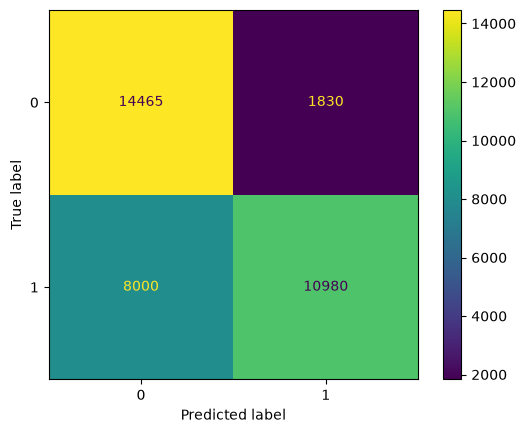

In [106]:
# Матрица ошибок
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

display(confusion_matrix(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [107]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.89      0.75     16295
           1       0.86      0.58      0.69     18980

    accuracy                           0.72     35275
   macro avg       0.75      0.73      0.72     35275
weighted avg       0.76      0.72      0.72     35275



**Промежуточный вывод**

По матрице ошибок (порог 0.5):
- TN = 14 465, FP = 1 830, FN = 8 000, TP = 10 980
- модель чаще **пропускает реальные задержки** (FN), чем даёт ложные тревоги (FP)

По `classification_report` для класса задержки (1):
- precision ≈ **0.86** — если модель предупреждает о риске, она обычно права;
- recall ≈ **0.58** — находится только ~58% фактических задержек;
- f1 ≈ 0.69, accuracy ≈ 0.72

Для бизнеса это значит: ложных эскалаций мало, но часть проблемных заказов остаётся незамеченной. При необходимости можно снизить порог вероятности, чтобы поднять recall ценой большего числа FP.


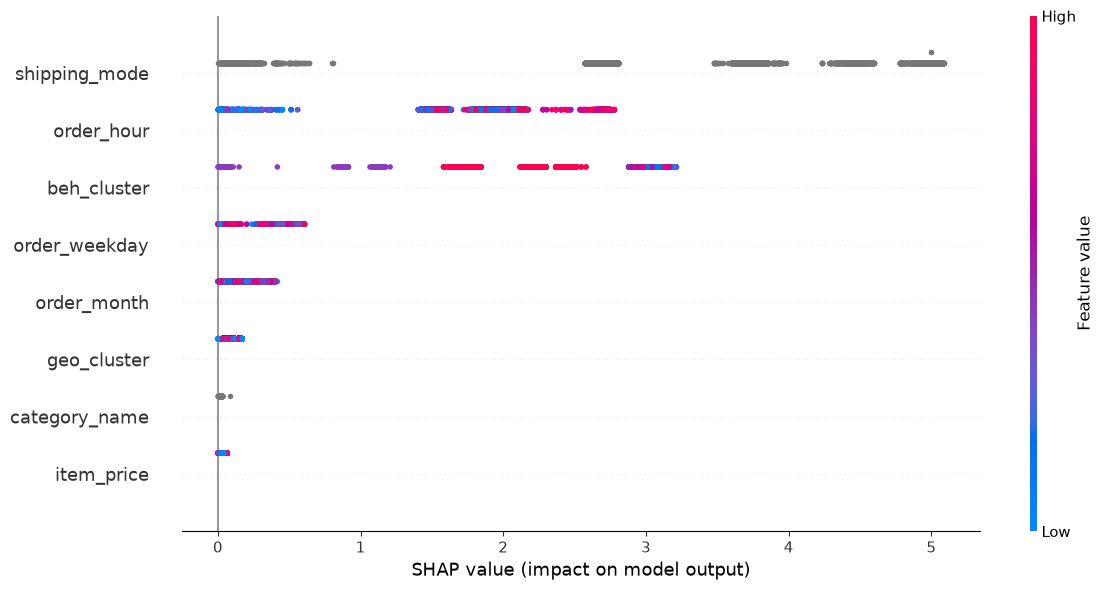

In [108]:
plt.figure(figsize=(12, 6))

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False, plot_size=None, max_display=10)

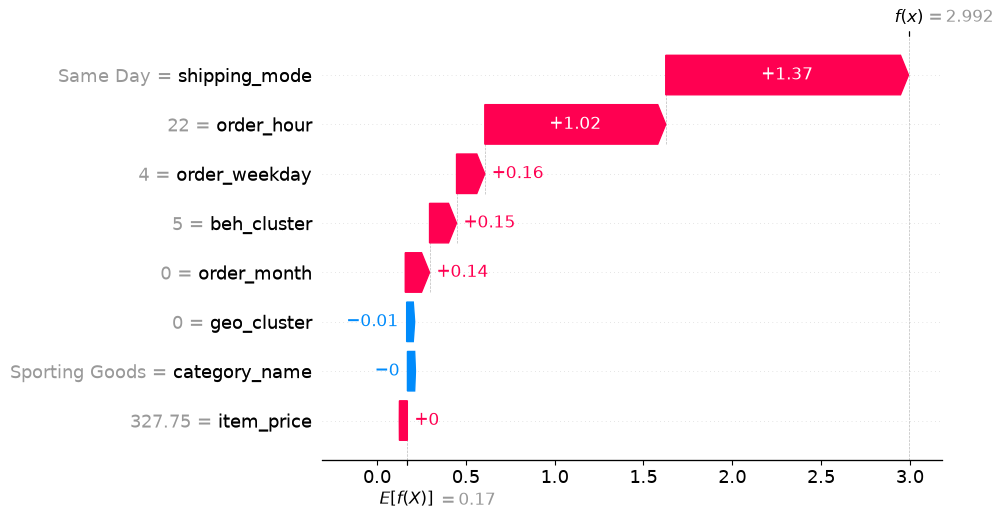

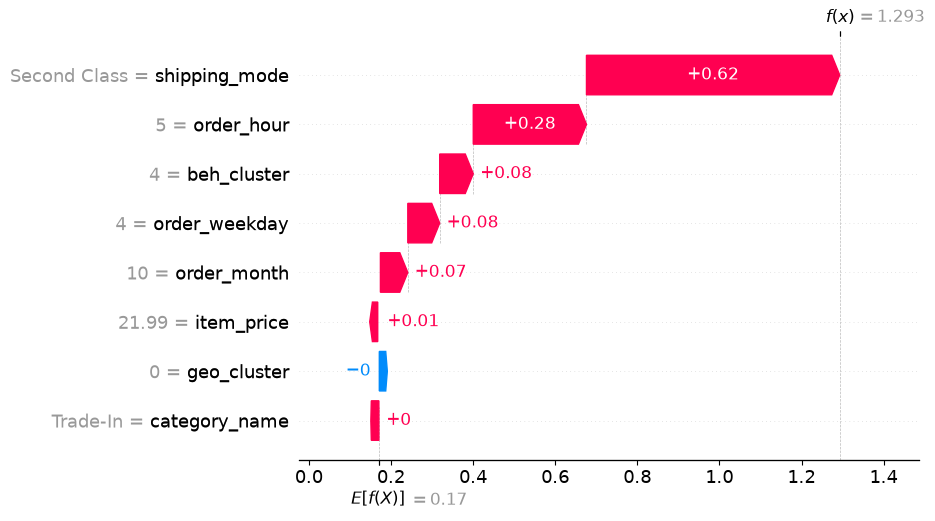

In [109]:
# Пример влияния признаков на прогноз пары случайных заказов
shap.plots.waterfall(shap_values[10])
shap.plots.waterfall(shap_values[13])

**Промежуточный вывод**

По SHAP порядок важности такой: `shipping_mode`, `order_hour`, `beh_cluster`, затем с большим отрывом `order_weekday`, `order_month`, `geo_cluster`, `category_name`, `item_price`.

- решают режим доставки и час заказа;
- из кластеров работает только поведенческий (`beh_cluster`, 3-е место) — профиль клиента полезен, но именно поведение, а не география;
- `geo_cluster` практически не влияет: географическая сегментация в присутствии остальных признаков сигнала почти не добавляет;
- `category_name`, `item_price` и остальной календарь тоже почти не влияют.

Гипотеза подтверждается частично: профиль клиента добавляет сигнал через поведенческие сегменты, но самый сильный фактор — режим доставки.

По waterfall видно направление вклада: для первого примера `order_hour = 22` даёт +1.02 к прогнозу риска, `shipping_mode = Same Day` — +1.37. Для второго `shipping_mode = Second Class` даёт +0.62, `order_hour = 5` — +0.28. То есть ускоренные режимы доставки модель справедливо считает более «опасными» (жёсткий SLA), а вклад часа заказа стабильно положительный — модель не пытается «спасать» ранние или поздние часы, а поднимает риск для большинства не-утренних значений (см. summary_plot: облако точек `order_hour` смещено вправо от нуля).


##  Выводы и рекомендации

### Результаты моделирования

Итоговая модель — **CatBoost** с признаками заказа и кластерами клиента (`geo_k=9`, `beh_k=8`).

| Модель | Выборка | ROC-AUC |
|---|---|---|
| LogReg baseline | val | 0.732 |
| CatBoost baseline | val | 0.805 |
| CatBoost + кластеры (фикс. K) | val | **0.810** |
| CatBoost + подбор K | val | 0.809 |
| **Итоговый CatBoost** | **test** | **0.801** |

Целевой порог **0.75 на тесте уверенно достигнут** (0.801). Относительно базового CatBoost прирост на val ≈ **+0.005** (0.805 → 0.810), спад val→test минимальный (0.810 → 0.801) — модель не переобучилась под валидацию.

При пороге 0.5 модель чаще **пропускает задержки** (FN), чем даёт ложные тревоги (FP): precision класса 1 ≈ 0.86, recall ≈ 0.58.

### Эффективность сегментации

Гипотеза подтвердилась частично: профиль клиента влияет на риск задержки, но только поведенческий.
- У линейной модели кластеры дают ощутимый прирост (~+0.011: 0.732 → 0.743), у CatBoost скромнее (~+0.005: 0.805 → 0.810).
- По SHAP в топ-3 входит **`beh_cluster`**, а **`geo_cluster` практически не влияет** — географическая сегментация дополнительного сигнала почти не приносит.
- Главный драйвер всё же **`shipping_mode`**, затем `order_hour`; цена и категория товара почти не влияют.

Визуализации: карта geo-зон, t-SNE поведенческих сегментов, SHAP summary — в соответствующих разделах выше.

### Технический инсайт

Итоговая модель использует **K_geo = 9** (по методу локтя) и **K_beh = 8** (по методу локтя). Совместный подбор K вместе с гиперпараметрами CatBoost остановился на `geo_k=4`, `beh_k=18`, но по метрике не превзошёл вариант с фиксированными K (val 0.809 против 0.810 — эффект в пределах шума), поэтому в качестве финальной берётся модель с K, выбранными по локтю. Scaler и K-Means обучались только на train-клиентах — без утечки в val/test.

Отдельно стоит отметить вклад корректной подачи календарных признаков: перевод часа/дня/месяца в `cat_features` у CatBoost поднял базовый ROC-AUC до 0.805, хотя φk оценивал связь часа с таргетом как слабую (≈ 0.07).

### Бизнес-рекомендации для CargaPronto

1. В момент оформления заказа считать вероятность задержки; при высоком риске (например >0.7) поднимать приоритет сборки или предлагать более быстрый `shipping_mode`.
2. Отдельно сопровождать «проблемные» поведенческие сегменты (высокий `return_rate`) — заранее закладывать запас по SLA. Гео-сегменты для прогноза оказались малополезны, их можно использовать скорее для планирования маршрутов, чем для оценки риска.
3. Учитывать час заказа: часть риска связана с `order_hour`, не только с адресом клиента.
4. Помнить про баланс ошибок: текущий порог даёт мало ложных тревог, но пропускает часть задержек — для минимизации штрафов SLA порог можно снизить, приняв больше ложных эскалаций.

**Итог:** сегментация клиентов усиливает прогноз, но операционно критичны режим доставки и своевременная реакция на высокий риск уже при создании заказа.
